They say comparison is the thief of joy, but I was robbed of that long ago so let's compare our two models.

In [1]:
import pandas as pd
import matplotlib.pyplot as plt

df_yolo = pd.read_csv("../data/yolo_keypoints.csv")
df_mp = pd.read_csv("../data/mediapipe_keypoints.csv")

## Visualization

### Hip

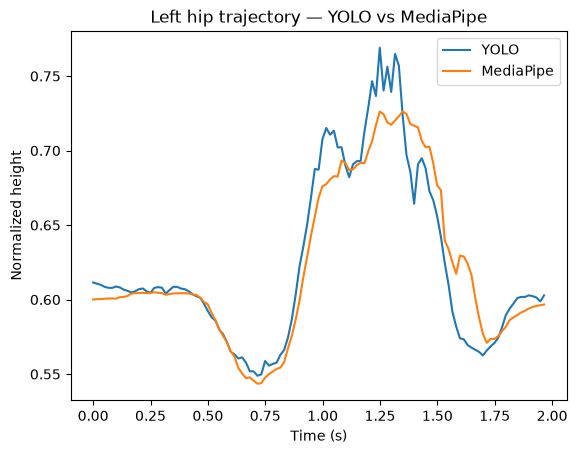

In [2]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "left_hip"]
mp_hip = df_mp[df_mp["keypoint"] == "left_hip"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left hip trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

First impression, mp looks less noisy and more stable especially betwwen 1s and 1.5s. </br>
Now we do the same for other body joints:

### Knee

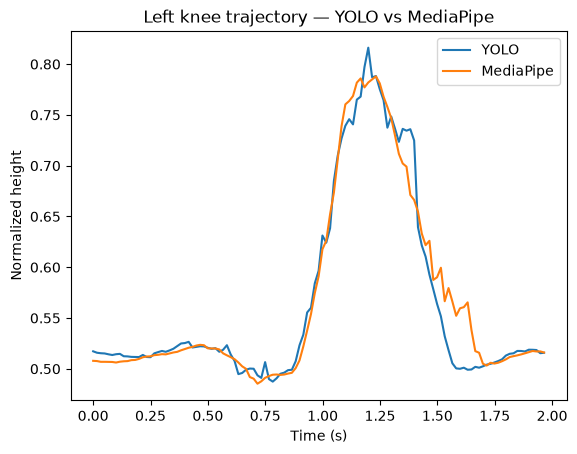

In [3]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "left_knee"]
mp_hip = df_mp[df_mp["keypoint"] == "left_knee"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left knee trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

### Ankle

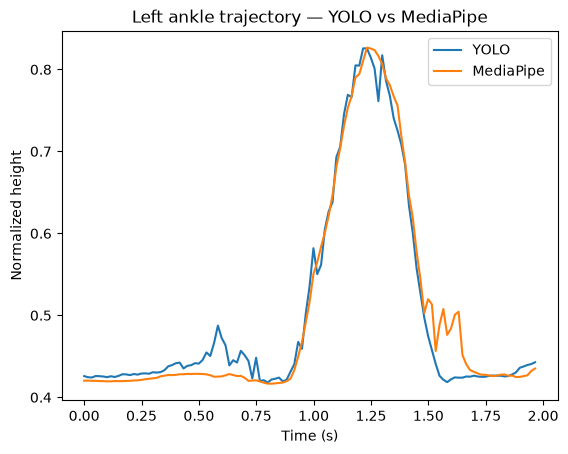

In [5]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "left_ankle"]
mp_hip = df_mp[df_mp["keypoint"] == "left_ankle"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left ankle trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

### Shoulder

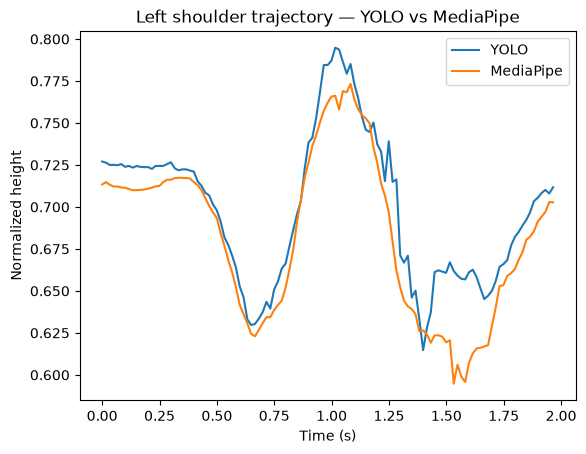

In [4]:
yolo_hip = df_yolo[df_yolo["keypoint"] == "left_shoulder"]
mp_hip = df_mp[df_mp["keypoint"] == "left_shoulder"]

plt.plot(
    yolo_hip["time"],
    1 - yolo_hip["y"],
    label="YOLO"
)

plt.plot(
    mp_hip["time"],
    1 - mp_hip["y"],
    label="MediaPipe"
)

plt.xlabel("Time (s)")
plt.ylabel("Normalized height")
plt.title("Left shoulder trajectory — YOLO vs MediaPipe")
plt.legend()

plt.show()

## Video monitoring


Yolo automatically creates the annotated video for you and saves it in a runs/pose folder. For those who do not want to run all the repo, I pushed the annotated video in assets/yolo_prediction. If you watch it, you will see the model strugling with the left shoulder between 1s and 1.5s.

However, MP does not provide the same service as easily.

In [ ]:
import cv2
import mediapipe as mp
import pandas as pd
import matplotlib.pyplot as plt

BaseOptions = mp.tasks.BaseOptions
PoseLandmarker = mp.tasks.vision.PoseLandmarker
PoseLandmarkerOptions = mp.tasks.vision.PoseLandmarkerOptions
VisionRunningMode = mp.tasks.vision.RunningMode

model_path = "../models/pose_landmarker_full.task"
options = PoseLandmarkerOptions(base_options = BaseOptions(model_asset_path=model_path), running_mode=VisionRunningMode.VIDEO)
landmarker = mp.tasks.vision.PoseLandmarker.create_from_options(options)

LANDMARKS = ["nose","left_eye_inner","left_eye","left_eye_outer","right_eye_inner","right_eye","right_eye_outer","left_ear","right_ear","mouth_left","mouth_right","left_shoulder","right_shoulder","left_elbow","right_elbow","left_wrist","right_wrist","left_pinky","right_pinky","left_index","right_index","left_thumb","right_thumb","left_hip","right_hip","left_knee","right_knee","left_ankle","right_ankle","left_heel","right_heel","left_foot_index","right_foot_index"]







video_path = "../assets/backflip.mov" # -------------------


def mp_annotate_video(video_path, output_path, options):


cap = cv2.VideoCapture(video_path)

fps = cap.get(cv2.CAP_PROP_FPS)

rows = []
frame_index = 0

with PoseLandmarker.create_from_options(options) as landmarker:

    while True:
    
        success, frame = cap.read()

        if not success:
            break

        # open frame with opencv
        frame_rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)

       # np array to mp Image
        mp_image = mp.Image(image_format = mp.ImageFormat.SRGB, data = frame_rgb)

        #timestamp
        timestamp_ms = int(frame_index*1000/fps)

       # inference
        result = landmarker.detect_for_video(mp_image,timestamp_ms=timestamp_ms)

        # pose detected
        if result.pose_landmarks:

            # first person detected
            pose = result.pose_landmarks[0]

            # keeping the 33 landmarks
            for i, landmark in enumerate(pose):

                rows.append({
                    "frame": frame_index,
                    "time": frame_index / fps,
                    "keypoint": LANDMARKS[i],
                    "x": landmark.x,
                    "y": landmark.y,
                    "z": landmark.z,
                    "visibility": landmark.visibility, # model thinks landmark is clearly visible in the image
                    "presence": landmark.presence # model thinks landmark exists in the image
                })


        frame_index += 1

cap.release()

df_mp = pd.DataFrame(rows)

display(df_mp.head())
print(df_mp.shape)